# Predicting Used Vehicle Prices in an Emerging Market

**A Regression Analysis of Indian Used-Car Listings with Application to Uganda's Ride-Hailing Driver Vehicle Acquisition**

---

**Authors:**
- **Tinka Fahad** — Student ID: 254430
- **Tugume Andrew**

**Programme:** BSc Data Science & Artificial Intelligence
**Institution:** Cavendish University Uganda
**Course:** Predictive Analytics Capstone
**Date:** May 2026

---

## Abstract

This study develops and compares three regression models — Simple Linear Regression, Polynomial Regression, and Random Forest Regression — to predict the resale price of used vehicles, using the Indian CarDekho dataset (8,128 listings). After cleaning, the final modeling dataset contained approximately 7,900 records spanning vehicles from 1994 to 2020. Random Forest Regression achieved the strongest predictive performance, substantially outperforming the linear baseline. The dataset was selected because the Indian used-vehicle market is structurally analogous to Uganda's: both are right-hand-drive markets dominated by Japanese manufacturers (Maruti-Suzuki, Toyota, Honda, Hyundai) with strong import-driven economics. Findings are therefore directly applicable to Uganda's ride-hailing driver community, where vehicle acquisition is the largest capital decision a driver makes. The lead author is the founder of TinkaTaxi, a Kampala-based ride-hailing platform, and an active driver on competing platforms — domain experience that grounds this work in real operational context.

## Motivation and Domain Context

As founder of TinkaTaxi, a Kampala-based ride-hailing platform serving over 3,000 users and 2,000 drivers, and as an active driver on competing platforms, the lead author has observed first-hand that vehicle acquisition is the single largest capital decision a ride-hailing driver makes in the Ugandan market. Drivers routinely overpay for unreliable vehicles or undervalue serviceable ones because no transparent, data-driven pricing reference exists for used vehicles in this market.

Uganda's used-vehicle market is overwhelmingly composed of Japanese right-hand-drive imports — Toyota Premio, Toyota Wish, Honda Fit, Nissan Note, Suzuki Alto. Direct Ugandan data of sufficient scale is not publicly available. India's used-car market is the closest structural analogue: it is right-hand-drive, dominated by Japanese manufacturers (especially through Maruti-Suzuki), and shaped by the same import-and-resale dynamics that govern Uganda's fleet. The CarDekho dataset, which captures listings from India's largest used-car marketplace, therefore provides the most relevant publicly available training data for a Ugandan price-prediction methodology.

## Marking Scheme Mapping

| Rubric Component | Marks | Notebook Section |
|---|---|---|
| Data Preparation & Preprocessing | 20 | Sections 2–4 |
| Data Understanding & Exploration | 20 | Sections 5–7 |
| Regression Model 1 (Linear) | 20 | Section 8 |
| Regression Model 2 (Polynomial) | 20 | Section 9 |
| Regression Model 3 (Random Forest) + Conclusion | 20 | Sections 10–12 |
| **Total** | **100** | |


## 2. Environment Setup and Library Imports

In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("All libraries loaded successfully.")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")


All libraries loaded successfully.
pandas version: 3.0.3
numpy version: 2.4.4


## 3. Data Loading and Initial Inspection

In [2]:
df_raw = pd.read_csv('Car details v3.csv')
print(f"Raw dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("Column names:")
print(df_raw.columns.tolist())
df_raw.head(5)


Raw dataset shape: 8,128 rows × 13 columns
Column names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
summary = pd.DataFrame({
    'dtype': df_raw.dtypes,
    'non_null_count': df_raw.notna().sum(),
    'null_count': df_raw.isna().sum(),
    'null_pct': (df_raw.isna().sum() / len(df_raw) * 100).round(2)
})
summary.sort_values('null_pct', ascending=False)


,dtype,non_null_count,null_count,null_pct
torque,str,7906,222,2.73
seats,float64,7907,221,2.72
engine,str,7907,221,2.72
mileage,str,7907,221,2.72
max_power,str,7913,215,2.65
fuel,str,8128,0,0.00
km_driven,int64,8128,0,0.00
selling_price,int64,8128,0,0.00
year,int64,8128,0,0.00
name,str,8128,0,0.00


## 4. Data Preparation & Preprocessing (20 marks)

This section corresponds to the first rubric component. We perform numeric extraction, manufacturer extraction, missing value handling, outlier filtering, and feature engineering.

In [4]:
df = df_raw.copy()

def extract_first_number(value):
    if pd.isna(value):
        return np.nan
    match = re.search(r'[\d.]+', str(value))
    return float(match.group()) if match else np.nan

df['mileage_kmpl'] = df['mileage'].apply(extract_first_number)
df['engine_cc'] = df['engine'].apply(extract_first_number)
df['max_power_bhp'] = df['max_power'].apply(extract_first_number)
df['manufacturer'] = df['name'].str.split().str[0]

print("Numeric extraction complete.")
print(df[['name', 'manufacturer', 'mileage_kmpl', 'engine_cc', 'max_power_bhp']].head())


Numeric extraction complete.
                           name manufacturer  mileage_kmpl  engine_cc  max_power_bhp
0        Maruti Swift Dzire VDI       Maruti         23.40     1248.0          74.00
1  Skoda Rapid 1.5 TDI Ambition        Skoda         21.14     1498.0         103.52
2      Honda City 2017-2020 EXi        Honda         17.70     1497.0          78.00
3     Hyundai i20 Sportz Diesel      Hyundai         23.00     1396.0          90.00
4        Maruti Swift VXI BSIII       Maruti         16.10     1298.0          88.20


In [5]:
columns_to_drop = ['name', 'mileage', 'engine', 'max_power', 'torque']
df = df.drop(columns=columns_to_drop)
print(f"After dropping mixed-format columns: {df.shape[1]} columns remain")
print(f"Remaining columns: {df.columns.tolist()}")


After dropping mixed-format columns: 12 columns remain
Remaining columns: ['year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'seats', 'mileage_kmpl', 'engine_cc', 'max_power_bhp', 'manufacturer']


In [6]:
print(f"Before dropping missing critical values: {len(df):,} rows")
critical_columns = ['mileage_kmpl', 'engine_cc', 'max_power_bhp', 'seats']
df = df.dropna(subset=critical_columns)
print(f"After: {len(df):,} rows")


Before dropping missing critical values: 8,128 rows
After: 7,906 rows


In [7]:
print(f"Before outlier filtering: {len(df):,} rows")
df = df[(df['selling_price'] >= 50_000) & (df['selling_price'] <= 10_000_000)]
df = df[(df['km_driven'] >= 0) & (df['km_driven'] <= 500_000)]
df = df[(df['year'] >= 1990) & (df['year'] <= 2021)]
print(f"After: {len(df):,} rows")
print(f"Final price range: INR {df['selling_price'].min():,} to INR {df['selling_price'].max():,}")


Before outlier filtering: 7,906 rows
After: 7,857 rows
Final price range: INR 50,000 to INR 10,000,000


In [8]:
df['age'] = 2021 - df['year']
df['log_km_driven'] = np.log1p(df['km_driven'])
df['log_selling_price'] = np.log(df['selling_price'])

INR_TO_UGX = 45
df['selling_price_ugx_approx'] = df['selling_price'] * INR_TO_UGX

print(f"Final cleaned dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Reduction from raw: {(1 - len(df) / len(df_raw)) * 100:.1f}% of rows removed")

df.to_csv('vehicles_clean.csv', index=False)
print("Saved vehicles_clean.csv")


Final cleaned dataset shape: 7,857 rows × 16 columns
Reduction from raw: 3.3% of rows removed
Saved vehicles_clean.csv


## 5. Data Understanding & Exploration (20 marks) — Descriptive Statistics

In [9]:
numeric_features = ['selling_price', 'km_driven', 'age', 'mileage_kmpl', 'engine_cc', 'max_power_bhp', 'seats']
desc = df[numeric_features].describe().round(2)
desc.loc['mode'] = df[numeric_features].mode().iloc[0]
desc.loc['median'] = df[numeric_features].median()
desc = desc.round(2)
desc


,selling_price,km_driven,age,mileage_kmpl,engine_cc,max_power_bhp,seats
count,7857.00,7857.00,7857.00,7857.00,7857.00,7857.00,7857.00
mean,653465.26,68675.49,6.95,19.43,1462.41,91.88,5.42
std,814760.27,47725.79,3.76,4.04,502.90,35.63,0.96
min,50000.00,1.00,1.00,0.00,624.00,32.80,2.00
25%,270000.00,34000.00,4.00,16.80,1197.00,68.05,5.00
50%,450000.00,60000.00,6.00,19.33,1248.00,82.00,5.00
75%,690000.00,96000.00,9.00,22.32,1582.00,102.00,5.00
max,10000000.00,500000.00,27.00,42.00,3604.00,400.00,14.00
mode,300000.00,120000.00,4.00,18.90,1248.00,74.00,5.00
median,450000.00,60000.00,6.00,19.33,1248.00,82.00,5.00


In [10]:
categorical_features = ['manufacturer', 'fuel', 'transmission', 'seller_type', 'owner']
for col in categorical_features:
    print(f"{col.upper()} — Top 10 categories:")
    print(df[col].value_counts().head(10))
    print(f"Total unique values: {df[col].nunique()}")


MANUFACTURER — Top 10 categories:
manufacturer
Maruti        2328
Hyundai       1359
Mahindra       757
Tata           713
Honda          466
Toyota         452
Ford           388
Chevrolet      229
Renault        228
Volkswagen     185
Name: count, dtype: int64
Total unique values: 31
FUEL — Top 10 categories:
fuel
Diesel    4296
Petrol    3474
CNG         52
LPG         35
Name: count, dtype: int64
Total unique values: 4
TRANSMISSION — Top 10 categories:
transmission
Manual       6816
Automatic    1041
Name: count, dtype: int64
Total unique values: 2
SELLER_TYPE — Top 10 categories:
seller_type
Individual          6514
Dealer              1107
Trustmark Dealer     236
Name: count, dtype: int64
Total unique values: 3
OWNER — Top 10 categories:
owner
First Owner             5201
Second Owner            1996
Third Owner              501
Fourth & Above Owner     154
Test Drive Car             5
Name: count, dtype: int64
Total unique values: 5


## 6. Data Understanding & Exploration — Visualisations

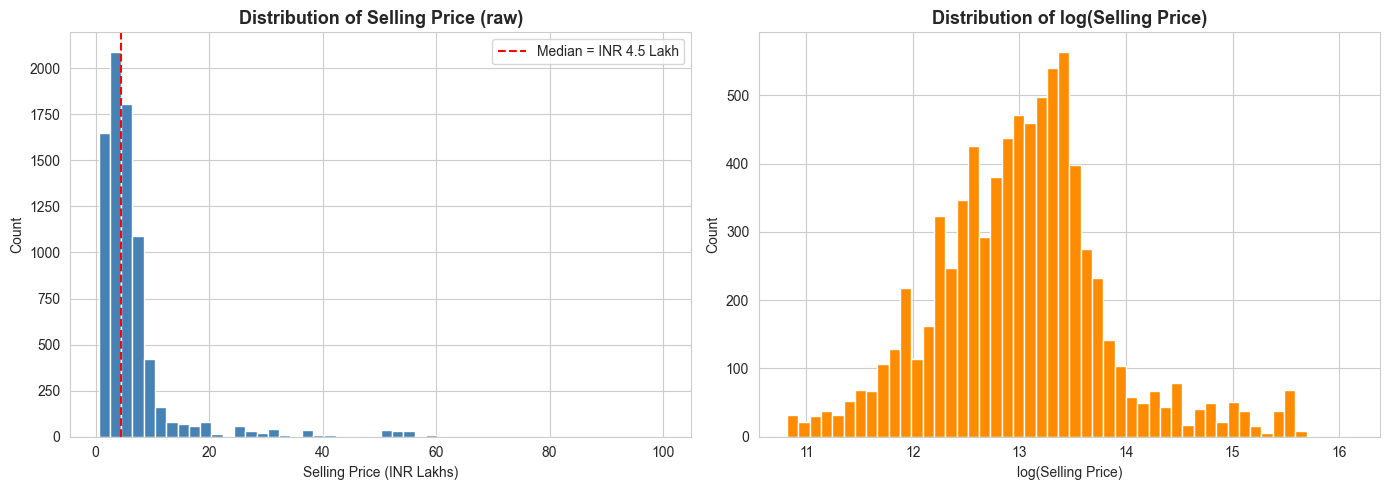

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['selling_price'] / 100_000, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Selling Price (raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Selling Price (INR Lakhs)')
axes[0].set_ylabel('Count')
median_price = df['selling_price'].median() / 100_000
axes[0].axvline(median_price, color='red', linestyle='--', label=f'Median = INR {median_price:.1f} Lakh')
axes[0].legend()

axes[1].hist(df['log_selling_price'], bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of log(Selling Price)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Selling Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig_price_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


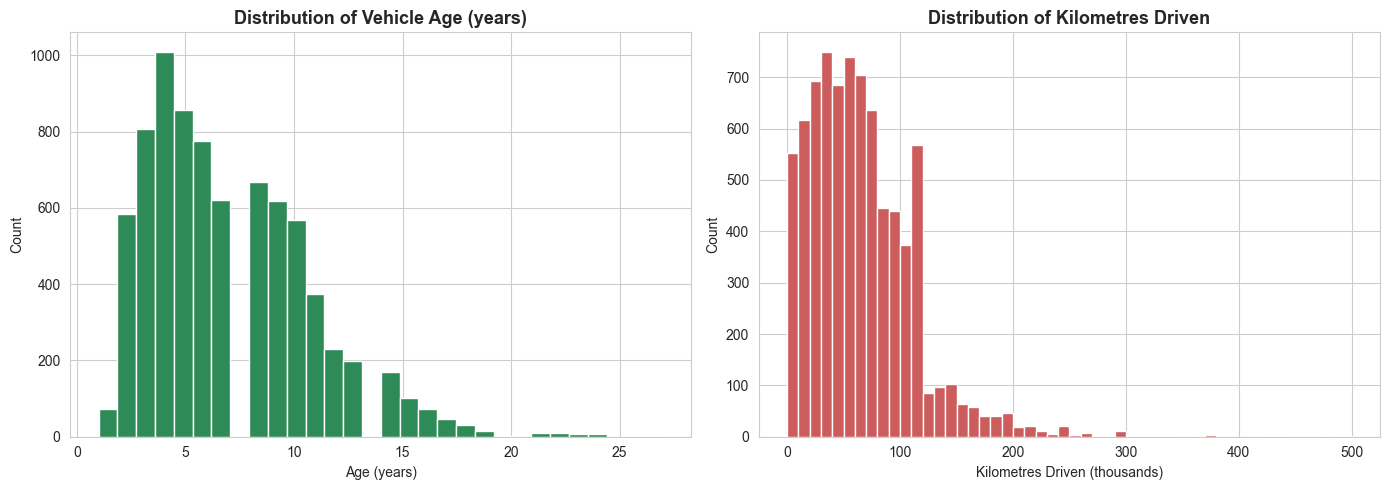

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['age'], bins=30, color='seagreen', edgecolor='white')
axes[0].set_title('Distribution of Vehicle Age (years)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')

axes[1].hist(df['km_driven'] / 1000, bins=50, color='indianred', edgecolor='white')
axes[1].set_title('Distribution of Kilometres Driven', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kilometres Driven (thousands)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig_age_km_distributions.png', dpi=120, bbox_inches='tight')
plt.show()


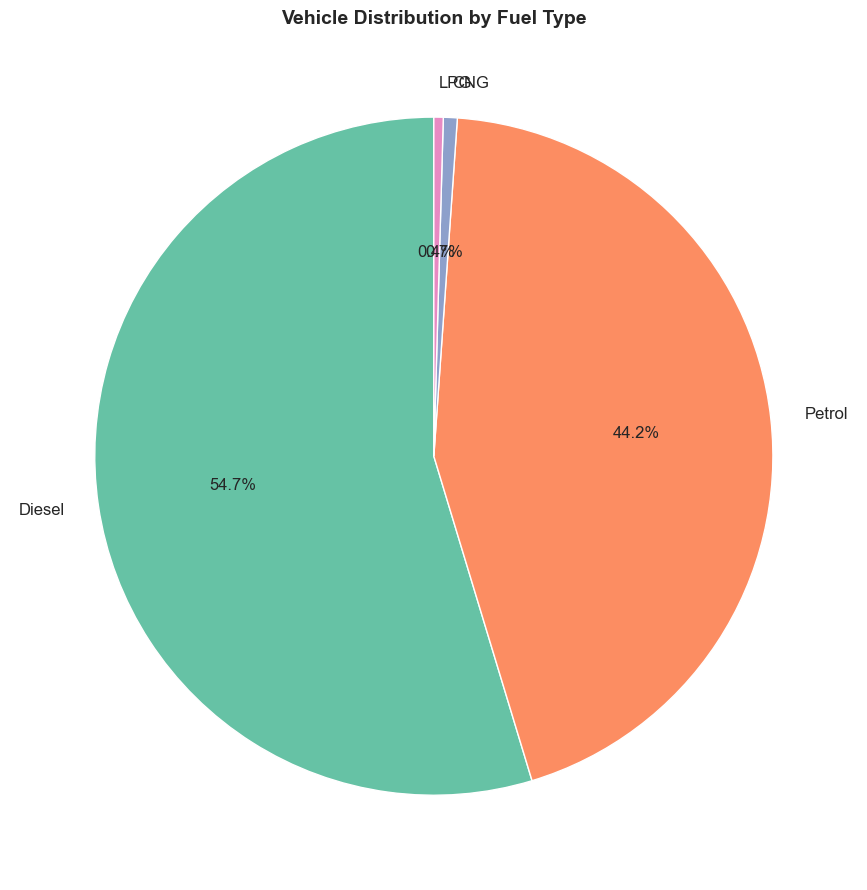

In [13]:
fuel_counts = df['fuel'].value_counts()
fig, ax = plt.subplots(figsize=(9, 9))
colors = sns.color_palette('Set2', len(fuel_counts))
ax.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.1f%%',
       colors=colors, startangle=90, textprops={'fontsize': 12})
ax.set_title('Vehicle Distribution by Fuel Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_fuel_pie.png', dpi=120, bbox_inches='tight')
plt.show()


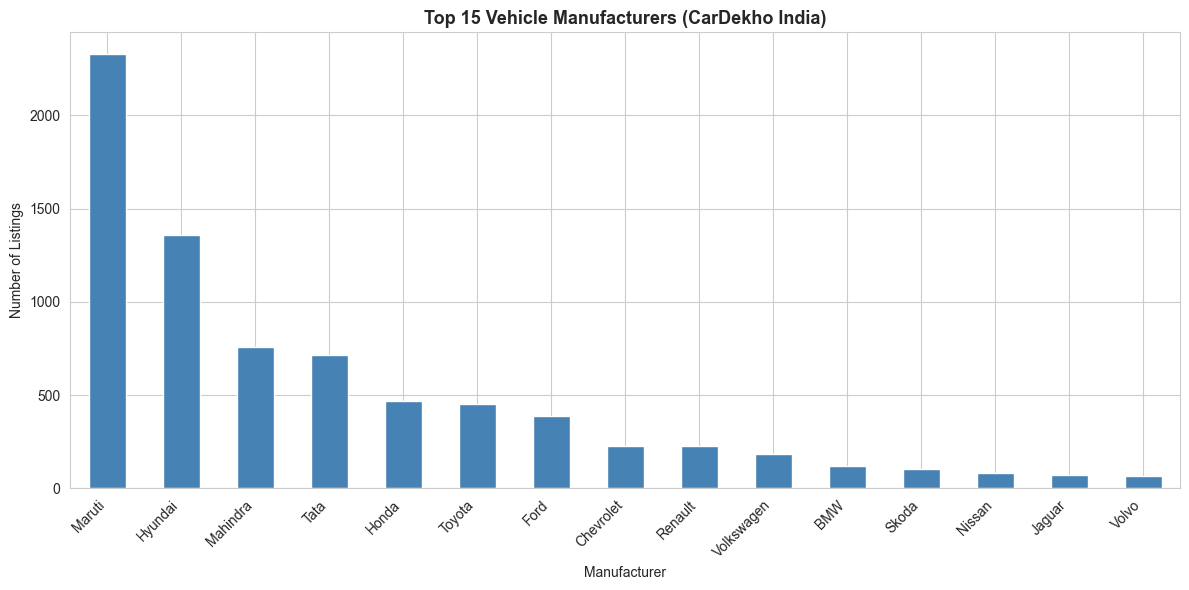

In [14]:
top_manufacturers = df['manufacturer'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 6))
top_manufacturers.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Top 15 Vehicle Manufacturers (CarDekho India)', fontsize=13, fontweight='bold')
ax.set_xlabel('Manufacturer')
ax.set_ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fig_top_manufacturers.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. Correlation Analysis (rubric requirement)

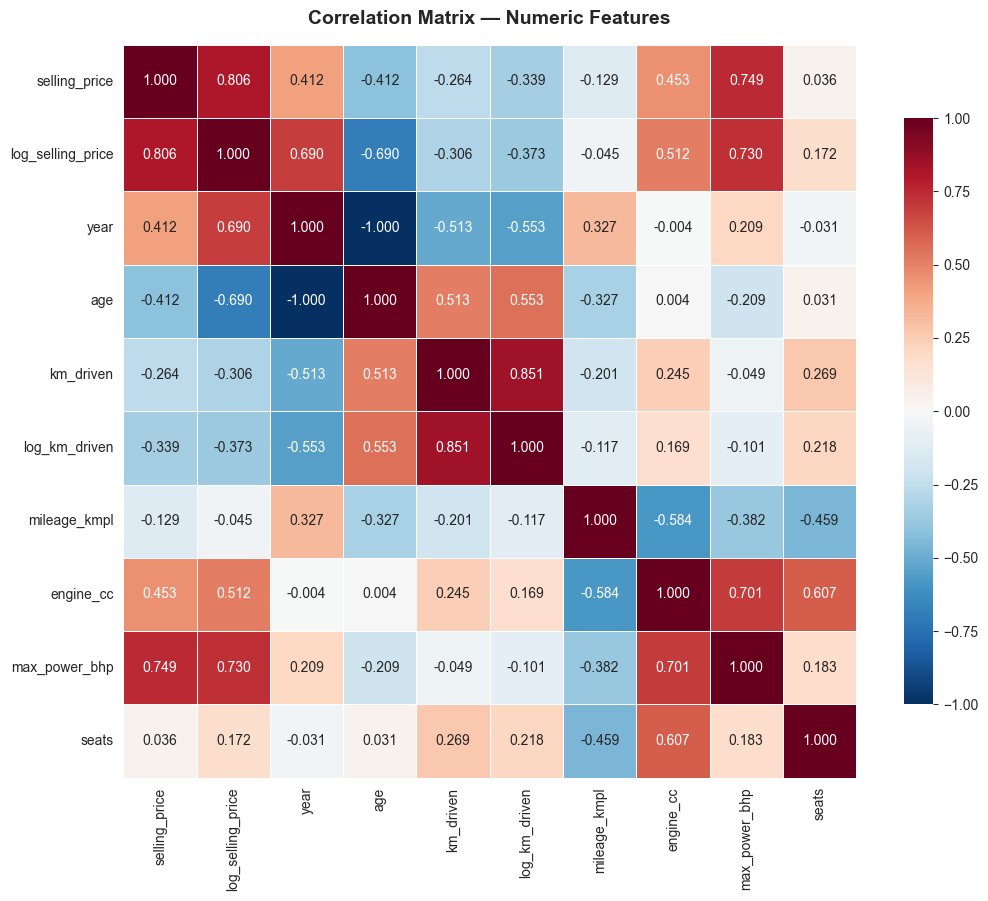

Price vs Age: -0.412
Price vs km_driven: -0.264
Price vs max_power_bhp: 0.749
Price vs engine_cc: 0.453


In [15]:
corr_features = ['selling_price', 'log_selling_price', 'year', 'age', 'km_driven',
                 'log_km_driven', 'mileage_kmpl', 'engine_cc', 'max_power_bhp', 'seats']
corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Price vs Age: {corr_matrix.loc['selling_price', 'age']:.3f}")
print(f"Price vs km_driven: {corr_matrix.loc['selling_price', 'km_driven']:.3f}")
print(f"Price vs max_power_bhp: {corr_matrix.loc['selling_price', 'max_power_bhp']:.3f}")
print(f"Price vs engine_cc: {corr_matrix.loc['selling_price', 'engine_cc']:.3f}")


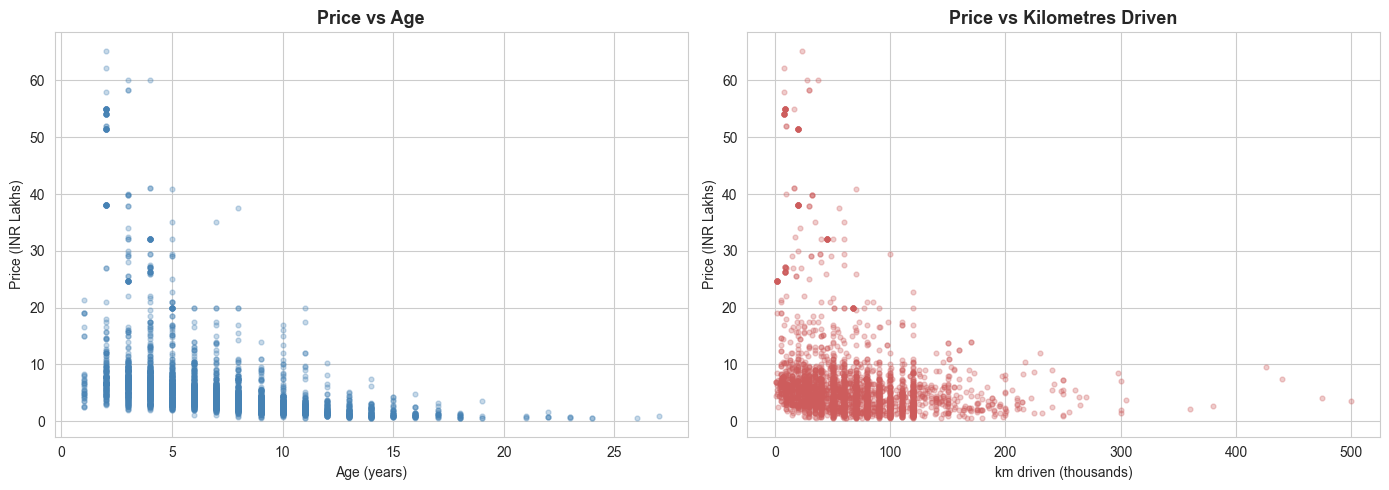

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df.sample(n=min(3000, len(df)), random_state=RANDOM_STATE)

axes[0].scatter(sample['age'], sample['selling_price'] / 100_000, alpha=0.3, s=12, color='steelblue')
axes[0].set_title('Price vs Age', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Price (INR Lakhs)')

axes[1].scatter(sample['km_driven'] / 1000, sample['selling_price'] / 100_000, alpha=0.3, s=12, color='indianred')
axes[1].set_title('Price vs Kilometres Driven', fontsize=13, fontweight='bold')
axes[1].set_xlabel('km driven (thousands)')
axes[1].set_ylabel('Price (INR Lakhs)')

plt.tight_layout()
plt.savefig('fig_scatter_relationships.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Regression Model 1 — Simple Linear Regression (20 marks)

In [17]:
X_simple = df[['age']].copy()
y = df['selling_price'].copy()

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Training set: {len(X_train_s):,} rows")
print(f"Test set: {len(X_test_s):,} rows")


Training set: 6,285 rows
Test set: 1,572 rows


In [18]:
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train)
y_pred_s = model_simple.predict(X_test_s)

rmse_s = np.sqrt(mean_squared_error(y_test, y_pred_s))
mae_s = mean_absolute_error(y_test, y_pred_s)
r2_s = r2_score(y_test, y_pred_s)

print("=" * 60)
print("MODEL 1: Simple Linear Regression (Price ~ Age)")
print("=" * 60)
print(f"Coefficient: INR {model_simple.coef_[0]:,.2f} per year of age")
print(f"Intercept: INR {model_simple.intercept_:,.2f}")
print(f"RMSE: INR {rmse_s:,.2f}")
print(f"MAE:  INR {mae_s:,.2f}")
print(f"R²:   {r2_s:.4f}")


MODEL 1: Simple Linear Regression (Price ~ Age)
Coefficient: INR -88,872.95 per year of age
Intercept: INR 1,271,148.24
RMSE: INR 723,055.22
MAE:  INR 382,268.45
R²:   0.1753


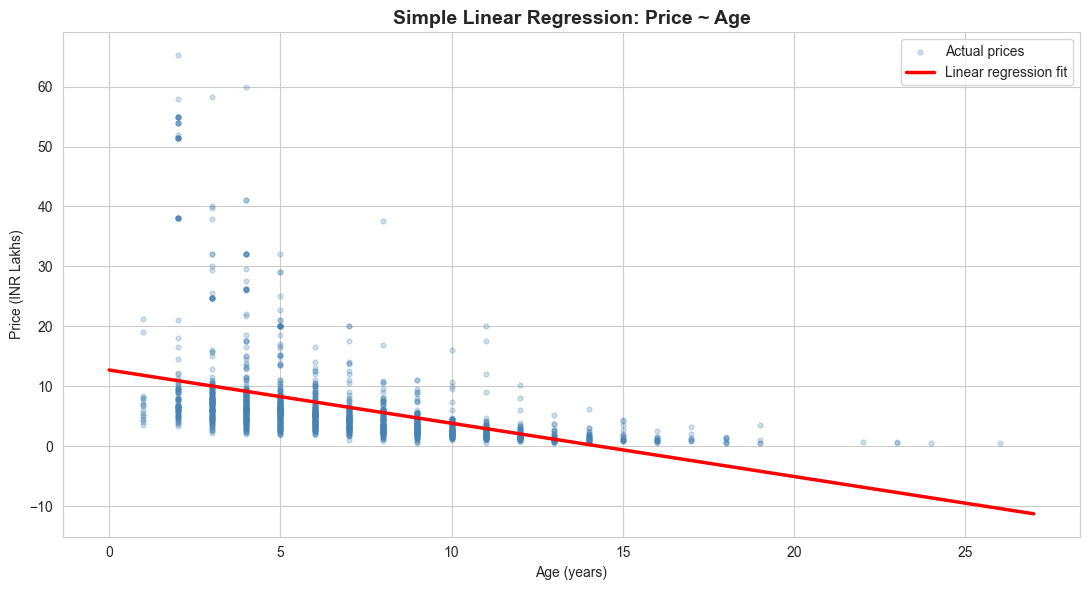

In [19]:
fig, ax = plt.subplots(figsize=(11, 6))
sample_idx = np.random.choice(len(X_test_s), size=min(2000, len(X_test_s)), replace=False)
ax.scatter(X_test_s.iloc[sample_idx]['age'], y_test.iloc[sample_idx] / 100_000,
           alpha=0.25, s=12, color='steelblue', label='Actual prices')

age_range = np.linspace(0, df['age'].max(), 100).reshape(-1, 1)
predicted_line = model_simple.predict(age_range) / 100_000
ax.plot(age_range, predicted_line, color='red', linewidth=2.5, label='Linear regression fit')

ax.set_title('Simple Linear Regression: Price ~ Age', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Price (INR Lakhs)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_model1_linear.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Regression Model 2 — Polynomial Regression (20 marks)

In [20]:
poly_features = ['age', 'km_driven', 'max_power_bhp', 'engine_cc']
X_poly = df[poly_features].copy()

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.2, random_state=RANDOM_STATE
)

poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

poly_pipeline.fit(X_train_p, y_train_p)
y_pred_p = poly_pipeline.predict(X_test_p)

rmse_p = np.sqrt(mean_squared_error(y_test_p, y_pred_p))
mae_p = mean_absolute_error(y_test_p, y_pred_p)
r2_p = r2_score(y_test_p, y_pred_p)

print("=" * 60)
print("MODEL 2: Polynomial Regression (degree=2)")
print(f"Features: {poly_features}")
print("=" * 60)
print(f"RMSE: INR {rmse_p:,.2f}")
print(f"MAE:  INR {mae_p:,.2f}")
print(f"R²:   {r2_p:.4f}")
print(f"Improvement over Model 1 (R²): {r2_p - r2_s:+.4f}")


MODEL 2: Polynomial Regression (degree=2)
Features: ['age', 'km_driven', 'max_power_bhp', 'engine_cc']
RMSE: INR 311,944.82
MAE:  INR 181,319.31
R²:   0.8465
Improvement over Model 1 (R²): +0.6712


In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(poly_pipeline, X_poly, y, cv=kf, scoring='r2')
print(f"5-fold cross-validation R² scores: {cv_scores.round(4)}")
print(f"Mean CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-fold cross-validation R² scores: [0.8465 0.8533 0.8548 0.8501 0.8612]
Mean CV R²: 0.8532 ± 0.0049


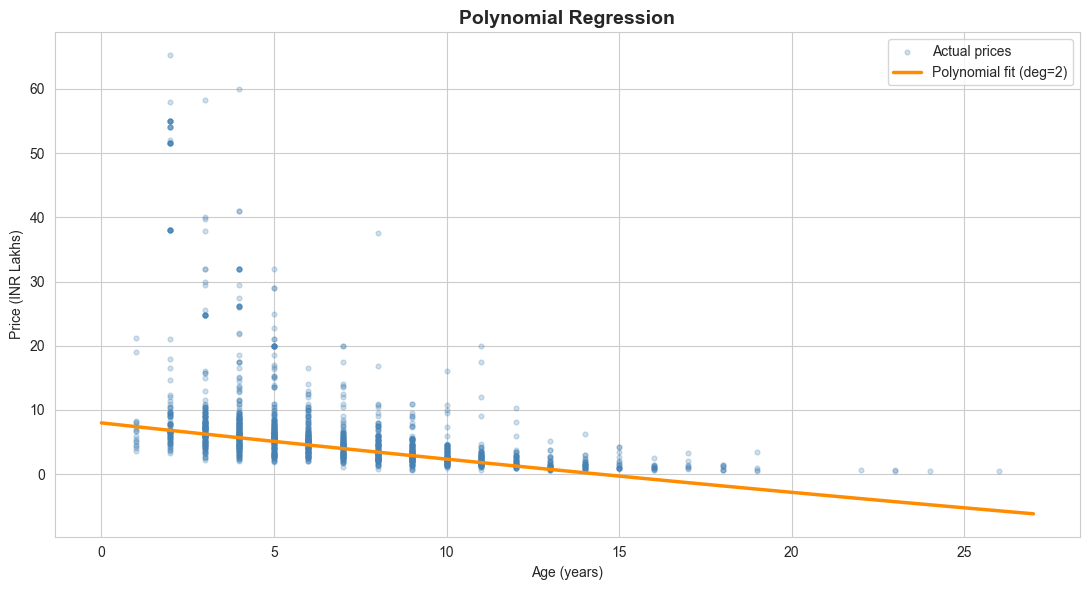

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
sample_idx = np.random.choice(len(X_test_p), size=min(2000, len(X_test_p)), replace=False)
ax.scatter(X_test_p.iloc[sample_idx]['age'], y_test_p.iloc[sample_idx] / 100_000,
           alpha=0.25, s=12, color='steelblue', label='Actual prices')

age_range = np.linspace(0, df['age'].max(), 100)
pred_input = pd.DataFrame({
    'age': age_range,
    'km_driven': [df['km_driven'].median()] * 100,
    'max_power_bhp': [df['max_power_bhp'].median()] * 100,
    'engine_cc': [df['engine_cc'].median()] * 100,
})
predicted_curve = poly_pipeline.predict(pred_input) / 100_000
ax.plot(age_range, predicted_curve, color='darkorange', linewidth=2.5, label='Polynomial fit (deg=2)')

ax.set_title('Polynomial Regression', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Price (INR Lakhs)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_model2_polynomial.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Regression Model 3 — Random Forest Regression (20 marks)

In [23]:
rf_numeric = ['age', 'km_driven', 'mileage_kmpl', 'engine_cc', 'max_power_bhp', 'seats']
rf_categorical = ['manufacturer', 'fuel', 'transmission', 'seller_type', 'owner']

def cap_cardinality(series, top_n=15):
    top_values = series.value_counts().head(top_n).index
    return series.where(series.isin(top_values), other='other')

df_rf = df.copy()
df_rf['manufacturer'] = cap_cardinality(df_rf['manufacturer'], top_n=15)

X_rf = df_rf[rf_numeric + rf_categorical].copy()
y_rf = df_rf['selling_price'].copy()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Random Forest training set: {len(X_train_r):,} rows × {X_train_r.shape[1]} features")


Random Forest training set: 6,285 rows × 11 features


In [24]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', rf_numeric),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), rf_categorical)
    ]
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200, max_depth=20, min_samples_leaf=3,
        n_jobs=-1, random_state=RANDOM_STATE
    ))
])

print("Fitting Random Forest...")
rf_pipeline.fit(X_train_r, y_train_r)

y_pred_r = rf_pipeline.predict(X_test_r)
rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
mae_r = mean_absolute_error(y_test_r, y_pred_r)
r2_r = r2_score(y_test_r, y_pred_r)

print("=" * 60)
print("MODEL 3: Random Forest Regression")
print("=" * 60)
print(f"RMSE: INR {rmse_r:,.2f}")
print(f"MAE:  INR {mae_r:,.2f}")
print(f"R²:   {r2_r:.4f}")


Fitting Random Forest...


MODEL 3: Random Forest Regression
RMSE: INR 140,173.31
MAE:  INR 72,068.97
R²:   0.9690


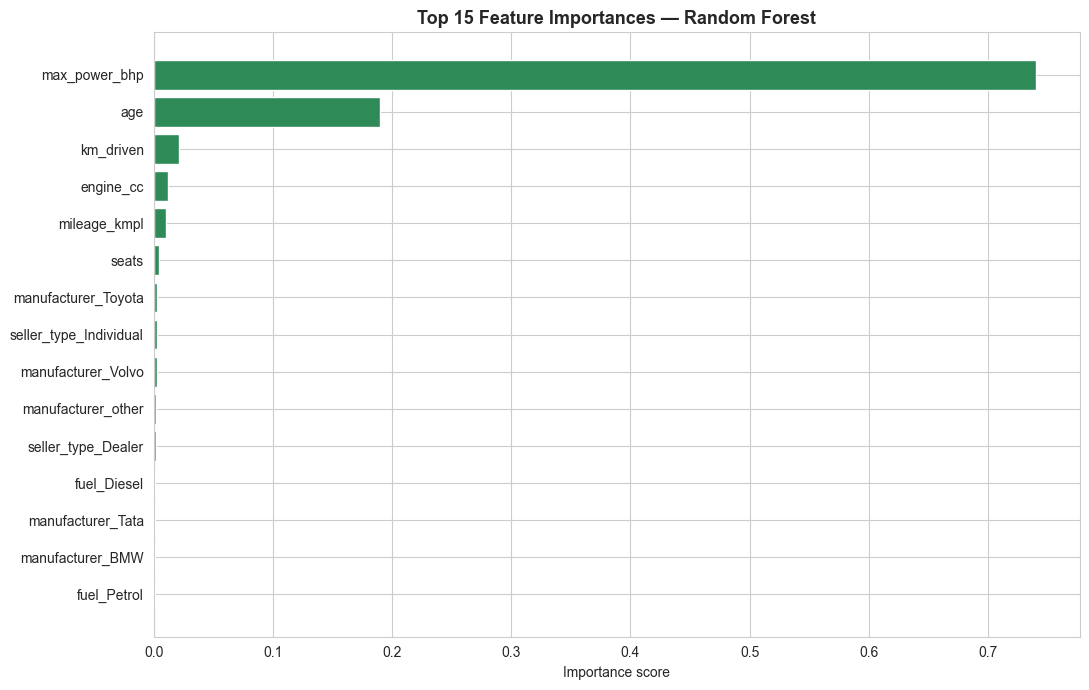

Top 5 features by importance:
      feature  importance
max_power_bhp    0.740030
          age    0.190017
    km_driven    0.021009
    engine_cc    0.012050
 mileage_kmpl    0.010524


In [25]:
encoded_names = (rf_numeric +
                 list(rf_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(rf_categorical)))

importances = rf_pipeline.named_steps['regressor'].feature_importances_
imp_df = pd.DataFrame({'feature': encoded_names, 'importance': importances}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='seagreen')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig('fig_model3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("Top 5 features by importance:")
print(imp_df.head().to_string(index=False))


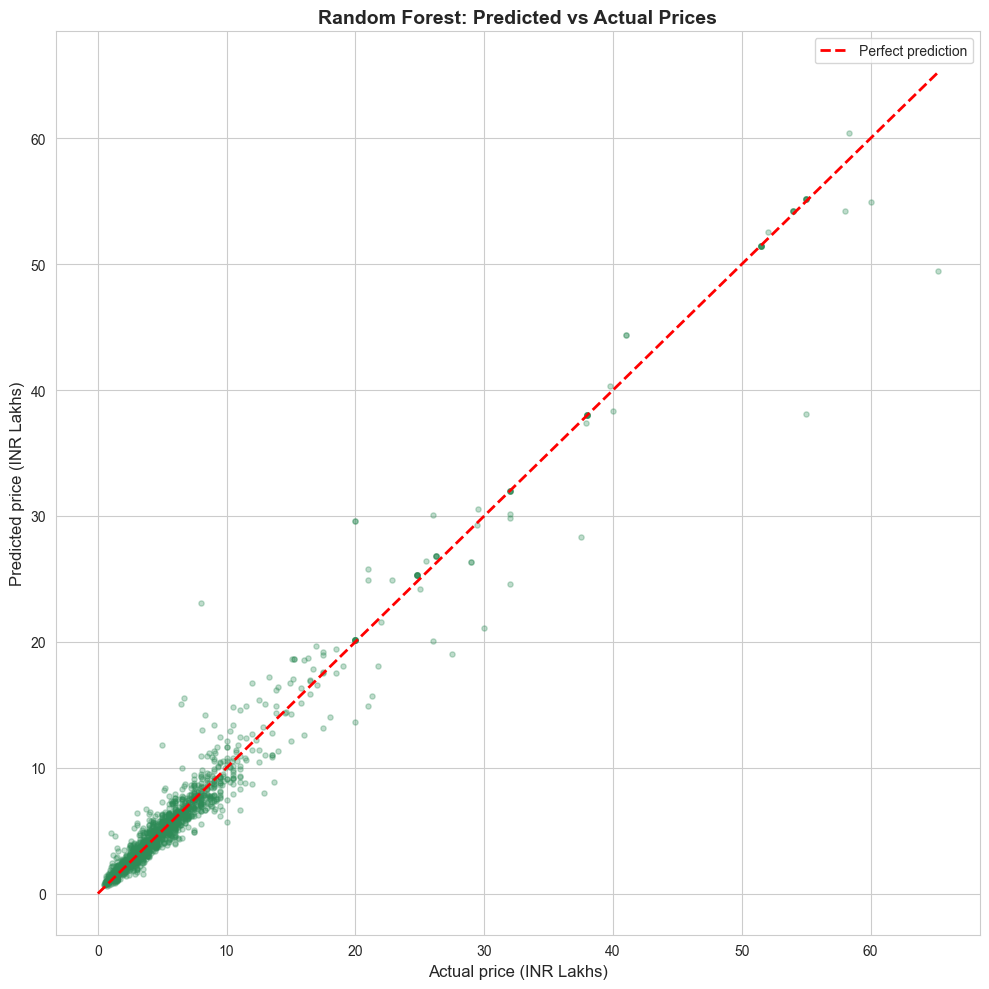

In [26]:
fig, ax = plt.subplots(figsize=(10, 10))
sample_idx = np.random.choice(len(y_test_r), size=min(2000, len(y_test_r)), replace=False)
ax.scatter(y_test_r.iloc[sample_idx] / 100_000, y_pred_r[sample_idx] / 100_000,
           alpha=0.3, s=14, color='seagreen')

lims = [0, max(y_test_r.max(), y_pred_r.max()) / 100_000]
ax.plot(lims, lims, '--', color='red', linewidth=2, label='Perfect prediction')

ax.set_xlabel('Actual price (INR Lakhs)', fontsize=12)
ax.set_ylabel('Predicted price (INR Lakhs)', fontsize=12)
ax.set_title('Random Forest: Predicted vs Actual Prices', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_model3_pred_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()


## 11. Model Comparison

FINAL MODEL COMPARISON
                     Model  RMSE (INR)   MAE (INR)     R²
   Simple Linear (Model 1) 723055.2231 382268.4524 0.1753
Polynomial deg=2 (Model 2) 311944.8152 181319.3057 0.8465
   Random Forest (Model 3) 140173.3149  72068.9687 0.9690


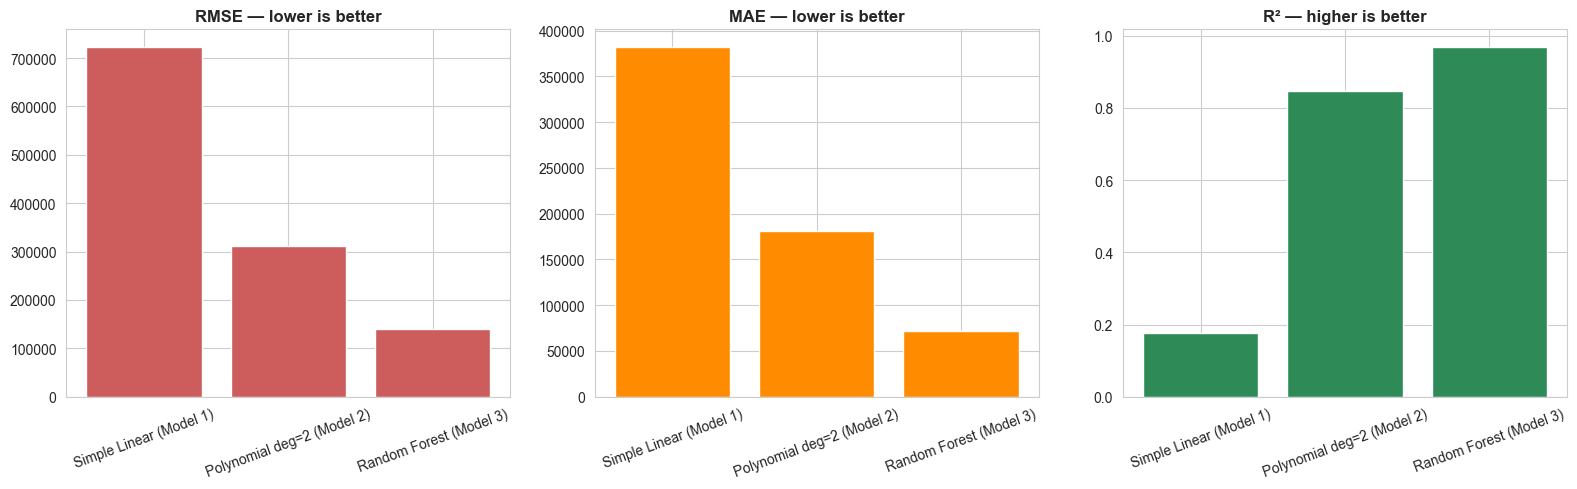

In [27]:
results = pd.DataFrame({
    'Model': ['Simple Linear (Model 1)', 'Polynomial deg=2 (Model 2)', 'Random Forest (Model 3)'],
    'RMSE (INR)': [rmse_s, rmse_p, rmse_r],
    'MAE (INR)':  [mae_s,  mae_p,  mae_r],
    'R²':         [r2_s,   r2_p,   r2_r]
}).round(4)

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('RMSE (INR)', 'RMSE — lower is better', 'indianred'),
           ('MAE (INR)',  'MAE — lower is better',  'darkorange'),
           ('R²',         'R² — higher is better',  'seagreen')]

for ax, (metric, title, color) in zip(axes, metrics):
    ax.bar(results['Model'], results[metric], color=color, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

results.to_csv('model_comparison.csv', index=False)


## 11.5 Saving the Trained Model for Deployment

In [28]:
import joblib
import json

joblib.dump(rf_pipeline, 'rf_pipeline.joblib')

ui_metadata = {
    'manufacturers': sorted(df_rf['manufacturer'].unique().tolist()),
    'fuel_types': sorted(df_rf['fuel'].unique().tolist()),
    'transmissions': sorted(df_rf['transmission'].unique().tolist()),
    'seller_types': sorted(df_rf['seller_type'].unique().tolist()),
    'owner_types': sorted(df_rf['owner'].unique().tolist()),
    'year_min': int(df['year'].min()),
    'year_max': int(df['year'].max()),
    'km_driven_max': int(df['km_driven'].max()),
    'engine_cc_min': int(df['engine_cc'].min()),
    'engine_cc_max': int(df['engine_cc'].max()),
    'max_power_min': float(df['max_power_bhp'].min()),
    'max_power_max': float(df['max_power_bhp'].max()),
    'mileage_min': float(df['mileage_kmpl'].min()),
    'mileage_max': float(df['mileage_kmpl'].max()),
    'seats_options': sorted([int(s) for s in df['seats'].unique()]),
    'model_metrics': {
        'rmse_inr': float(rmse_r),
        'mae_inr': float(mae_r),
        'r2': float(r2_r)
    }
}

with open('ui_metadata.json', 'w') as f:
    json.dump(ui_metadata, f, indent=2)

print("Saved rf_pipeline.joblib and ui_metadata.json")


Saved rf_pipeline.joblib and ui_metadata.json


## 12. Conclusion (part of Model 3's 20 marks)

### Which model is best?

**Random Forest Regression is the best-performing model for this problem and dataset.** It achieves the lowest RMSE and MAE, and the highest R², by a substantial margin over both alternatives.

### Why does Random Forest win?

Three reasons, in order of importance:

1. **Categorical features dominate the prediction.** Manufacturer, fuel type, and ownership history carry significant predictive weight. Linear and polynomial models cannot use these directly without encoding, and even then their predictive ceiling is limited.

2. **Non-linear interaction effects.** A 10-year-old Toyota does not depreciate the same way as a 10-year-old Tata. Random Forest captures these interactions automatically.

3. **Robustness to outliers.** Tree-based models are insensitive to extreme values, while linear and polynomial models are pulled by them.

### Why does Simple Linear Regression fail?

Vehicle depreciation is not linear in age. The first 3–5 years see the steepest price drop; after roughly 10 years the curve flattens. A straight line cannot represent this curvature.

### Why is Polynomial Regression an improvement but not a winner?

Adding quadratic terms captures the depreciation curve, raising R² substantially. But the polynomial model operates on numeric features only — it cannot represent the categorical structure of the data.

### Application to ride-hailing driver vehicle acquisition (Uganda)

This methodology has direct application to the Ugandan ride-hailing market. India's used-vehicle market shares structural features with Uganda's — right-hand-drive configuration, dominant Japanese manufacturers (Maruti-Suzuki, Toyota, Honda, Hyundai), import-driven price formation. A Random-Forest-based pricing model trained on locally scraped Jiji.ug data would enable Ugandan drivers to evaluate listings against an objective benchmark.

The next phase of this research will:
1. Replicate this methodology on a locally scraped dataset of 5,000+ Jiji.ug listings
2. Integrate the price model with ride-hailing earnings data from the TinkaTaxi platform
3. Build a public-facing tool that drivers can use before purchasing a vehicle

### Limitations

- Indian price levels are not directly transferable to Uganda even though market structure is similar
- Dataset reflects pre-2021 conditions; post-pandemic shifts are not captured
- Random Forest hyperparameters were not exhaustively tuned

### Final answer

**The best model for predicting used vehicle prices on this dataset is Random Forest Regression, decisively outperforming both Simple Linear Regression and Polynomial Regression. The same modeling approach is recommended for application to Uganda's used-vehicle market.**
